In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import scipy.sparse.linalg as spla
from scipy.ndimage import gaussian_filter1d
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge
import umap
import phate
import plotly.express as px

/home/reilly/miniconda3/envs/ai_scientist/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# CONFIG (caps)
# ============================================================
SEED = 42
MAT_PATH = "/home/reilly/Desktop/spontaneous_data/spont_M161025_MP030_20161120.mat"

DOWNSAMPLE_FACTOR = 4      # average within this many original samples
N_CELLS = 4_000
BLOCK_SIZE = 60 * (4 // DOWNSAMPLE_FACTOR)           # in downsampled time bins
TRAIN_TEST_SPLIT = "interleave"  # {"interleave", "half"}
# TRAIN_TEST_SPLIT = "half"

PLS_K = 16
RIDGE_ALPHA = 1.0
EPS = 1e-12

In [4]:
def downsample_mean_1d(x: np.ndarray, factor: int) -> np.ndarray:
    """
    Downsample a 1D array by averaging in non-overlapping windows.

    The array is cropped to a multiple of `factor` before downsampling.

    Args:
        x: Input array of shape (T,).
        factor: Window size for averaging.

    Returns:
        x_ds: Downsampled array of shape (T // factor,).
    """
    n = (len(x) // factor) * factor
    x = x[:n]
    return x.reshape(-1, factor).mean(axis=1)


def downsample_mean_2d(spks: np.ndarray, factor: int) -> np.ndarray:
    """
    Downsample a (cells x time) array by averaging across time in non-overlapping windows.

    The time axis is cropped to a multiple of `factor` before downsampling.

    Args:
        spks: Activity array of shape (n_cells, T).
        factor: Window size for averaging along time.

    Returns:
        spks_ds: Downsampled activity array of shape (n_cells, T // factor).
    """
    n = (spks.shape[1] // factor) * factor
    spks = spks[:, :n]
    return spks.reshape(spks.shape[0], -1, factor).mean(axis=2)


def zscore_rows(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Z-score each row of a 2D array independently.

    For each row i: (X_i - mean(X_i)) / (std(X_i) + eps).

    Args:
        X: Input array of shape (n_rows, n_cols).
        eps: Small constant to avoid division by zero.

    Returns:
        Xz: Row-wise z-scored array of shape (n_rows, n_cols).
    """
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True)
    return (X - mu) / (sd + eps)


def subsample_cells(spks: np.ndarray, n_cells: int, rng: np.random.Generator) -> np.ndarray:
    """
    Subsample cells (rows) without replacement.

    Args:
        spks: Activity array of shape (n_total_cells, T).
        n_cells: Number of cells to select.
        rng: NumPy random number generator.

    Returns:
        spks_sub: Subsampled activity array of shape (n_cells, T).
    """
    idx = rng.choice(spks.shape[0], size=n_cells, replace=False)
    return spks[idx]


def make_time_split(T: int, block_size: int, mode: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Split time indices into train/test by consecutive blocks.

    Two supported modes:
      - "interleave": even-numbered blocks -> train, odd-numbered blocks -> test
      - "half": first half of blocks -> train, second half -> test

    Args:
        T: Total number of timepoints.
        block_size: Block length in timepoints.
        mode: Either "interleave" or "half".

    Returns:
        train_t: 1D integer array of training time indices.
        test_t: 1D integer array of testing time indices.

    Raises:
        ValueError: If T < block_size or mode is invalid.
    """
    assert T >= 2 * block_size, "T must be at least 2 * block_size"
    assert mode in {"interleave", "half"}, "Invalid mode"

    if mode == "interleave":
        # update T to be an even multiple of block_size
        T = (T // block_size) * block_size
        n_blocks = T // block_size
        n_blocks = n_blocks - (n_blocks % 2)  # make even number of blocks
        train_t = np.concatenate([b * block_size + np.arange(block_size) for b in range(0, n_blocks, 2)])
        test_t = np.concatenate([b * block_size + np.arange(block_size) for b in range(1, n_blocks, 2)])
    else:
        # make T an even number
        T = T - (T % 2)
        train_t = np.arange(0, T // 2)
        test_t = np.arange(T // 2, T)

    return train_t, test_t


def split_cells(n_cells: int, rng: np.random.Generator, train_frac: float = 0.5) -> tuple[np.ndarray, np.ndarray]:
    """
    Randomly split cell indices into two disjoint halves.

    Args:
        n_cells: Total number of cells.
        rng: NumPy random number generator.
        train_frac: Fraction of cells to assign to training set.

    Returns:
        train_cells: Indices for source cells (size int(n_cells * train_frac)).
        test_cells: Indices for target cells (size n_cells - int(n_cells * train_frac)).
    """
    train_cells = rng.choice(n_cells, size=int(n_cells * train_frac), replace=False)
    test_cells = np.setdiff1d(np.arange(n_cells), train_cells)
    return train_cells, test_cells


def load_mat_spont(mat_path: str, var_thresh = 1e-4) -> tuple[np.ndarray, np.ndarray]:
    """
    Load spikes and running speed from a .mat file with the expected structure.

    Args:
        mat_path: Path to the .mat file.

    Returns:
        spks: Spike/activity matrix of shape (n_neurons, n_timepoints).
        run_speed: Running speed vector of shape (n_timepoints,).
    """
    mt = loadmat(mat_path)
    spks = mt["Fsp"]  # neurons x timepoints
    # remove cells with low variance (usually non-neural ROIs)
    cell_var = spks.var(axis=1)
    keep_cells = cell_var >= var_thresh
    spks = spks[keep_cells, :]
    run_speed = mt["beh"]["runSpeed"][0, 0][:, 0]  # timepoints,
    pupil_area = mt["beh"]["pupil"][0, 0][0, 0].item()[0][:, 0]  # timepoints,
    pupil_com = mt["beh"]["pupil"][0, 0][0, 0].item()[1]  # timepoints, 2
    # perform downsampling here
    spks = downsample_mean_2d(spks, DOWNSAMPLE_FACTOR)
    run_speed = downsample_mean_1d(run_speed, DOWNSAMPLE_FACTOR)
    pupil_area = downsample_mean_1d(pupil_area, DOWNSAMPLE_FACTOR)
    pupil_com = downsample_mean_2d(pupil_com.T, DOWNSAMPLE_FACTOR).T  # keep shape (time, 2)
    return spks, run_speed, pupil_area, pupil_com


def make_XY(
    spks: np.ndarray,
    train_cells: np.ndarray,
    test_cells: np.ndarray,
    train_t: np.ndarray,
    test_t: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Construct train/test design matrices as (time x cells).

    Args:
        spks: Activity array of shape (n_cells, T).
        train_cells: 1D integer array of source cell indices.
        test_cells: 1D integer array of target cell indices.
        train_t: 1D integer array of training time indices.
        test_t: 1D integer array of testing time indices.

    Returns:
    X and Y for train and test:
    X = [2 x n_source_cells x n_time]
    Y = [2 x n_target_cells x n_time]
    """
    X_train = spks[np.ix_(train_cells, train_t)]
    Y_train = spks[np.ix_(test_cells,  train_t)]
    X_test = spks[np.ix_(train_cells, test_t)]
    Y_test = spks[np.ix_(test_cells,  test_t)]
    return np.array([X_train, X_test]), np.array([Y_train, Y_test])

In [5]:
# Metrics
# ============================================================
def mse(A: np.ndarray, B: np.ndarray) -> float:
    """
    Compute mean squared error.

    Args:
        A: Ground-truth targets, shape (n_rows, n_cols).
        B: Predicted targets, shape (n_rows, n_cols).

    Returns:
        mse_value: Scalar mean squared error.
    """
    return float(np.mean((A - B) ** 2))


def per_row_corr(A: np.ndarray, B: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Compute Pearson correlation per row.

    Correlation is computed column-wise after mean-centering each column.

    Args:
        A: Ground-truth targets, shape (n_rows, n_cols).
        B: Predicted targets, shape (n_rows, n_cols).
        eps: Small constant added to the denominator for numerical stability.

    Returns:
        corr: 1D array of correlations of shape (n_rows,).
    """
    Ac = A - A.mean(axis=0, keepdims=True)
    Bc = B - B.mean(axis=0, keepdims=True)
    num = (Ac * Bc).sum(axis=1)
    den = np.sqrt((Ac * Ac).sum(axis=1) * (Bc * Bc).sum(axis=1)) + eps
    return num / den


def mean_row_corr(A: np.ndarray, B: np.ndarray, eps: float = 1e-12) -> float:
    """
    Compute the mean of per-row Pearson correlations.

    Args:
        A: Ground-truth targets, shape (n_rows, n_cols).
        B: Predicted targets, shape (n_rows, n_cols).
        eps: Small constant added to the denominator for numerical stability.

    Returns:
        mean_corr: Scalar mean correlation across target dimensions.
    """
    return float(np.nanmean(per_row_corr(A, B, eps=eps)))


def var_explained(A: np.ndarray, B: np.ndarray, eps: float = 1e-12) -> float:
    """
    Compute the mean of per-row variance explained (R^2).

    Args:
        A: Ground-truth targets, shape (n_rows, n_cols).
        B: Predicted targets, shape (n_rows, n_cols).
        eps: Small constant added to the denominator for numerical stability.
    Returns:
        mean_r2: Scalar mean R^2 across target dimensions.
    """
    Ac = A - A.mean(axis=1, keepdims=True)
    Bc = B - B.mean(axis=1, keepdims=True)
    ss_res = np.sum((Ac - Bc) ** 2, axis=1)
    ss_tot = np.sum(Ac ** 2, axis=1) + eps
    r2 = 1 - (ss_res / ss_tot)
    return float(np.nanmean(r2))


def concentration_metric(spks: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Compute a concentration metric for each cell's activity.

    The metric quantifies how concentrated the activity is over time,
    with values close to 1 indicating high concentration (e.g., bursts)
    and values close to 0 indicating more uniform activity.

    Args:
        spks: Activity array of shape (n_cells, T).
        eps: Small constant to avoid division by zero.
    Returns:
        conc: 1D array of concentration metrics of shape (n_cells,).
    """
    # assert that spks is not < 0
    smol = 1e-4
    assert np.all(spks >= -smol), "spks must be non-negative"
    t_max = spks.shape[1]
    num = np.sum(np.abs(spks), axis=1) ** 2
    den = t_max * np.sum(spks ** 2, axis=1) + eps
    beta = num / den
    conc = (1 - beta) / (1 - 1 / t_max)
    return conc


def noise_var_conditional_diff(Y, p=0.2, min_samples=10):
    """
    Estimate per-cell noise variance using conditional differencing.

    Parameters
    ----------
    Y : array, shape (N, T)
        Mean-centered time series (neurons × time).
    p : float
        Percentile threshold for baseline (e.g. 0.2 = 20th percentile).
    min_samples : int
        Minimum number of baseline samples before fallback.

    Returns
    -------
    sigma2 : array, shape (N,)
        Estimated noise variance per neuron.
    """
    N, T = Y.shape
    dY = Y[:, 1:] - Y[:, :-1]

    sigma2 = np.zeros(N)

    for i in range(N):
        tau = np.quantile(np.abs(Y[i]), p)
        mask = (np.abs(Y[i, :-1]) < tau) & (np.abs(Y[i, 1:]) < tau)

        if mask.sum() >= min_samples:
            sigma2[i] = 0.5 * np.var(dY[i, mask])
        else:
            sigma2[i] = 0.5 * np.var(dY[i])

    return np.maximum(sigma2, 1e-8)


In [6]:
def report_performance(Y_true_train, Y_pred_train, Y_true_test, Y_pred_test):
    corr_train = per_row_corr(Y_true_train, Y_pred_train)
    corr_test = per_row_corr(Y_true_test, Y_pred_test)
    mse_train = mse(Y_true_train, Y_pred_train)
    mse_test = mse(Y_true_test, Y_pred_test)
    var_explained_train = var_explained(Y_true_train, Y_pred_train)
    var_explained_test = var_explained(Y_true_test, Y_pred_test)
    print(f"Train Corr: {np.nanmean(corr_train):.4f}, Test Corr: {np.nanmean(corr_test):.4f}")
    print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")
    print(f"Train Var Explained: {var_explained_train:.4f}, Test Var Explained: {var_explained_test:.4f}")

In [7]:
def svca(X: np.ndarray, Y: np.ndarray, scale: bool = False, k: int = None) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute Shared Variance Component Analysis (SVCA). If scale is False, returns orthonormal basis for shared components.
    If scale is True, returns scaled components using singular values (still orthogonal, but not unit norm).

    Parameters
    ----------
    X : array, shape (N_source, T)
        Source activity (neurons × time).
    Y : array, shape (N_target, T)
        Target activity (neurons × time).
    scale : bool, optional
        If True, scale components using singular values (default is False).
    k : int or None, optional
        Number of components to return. If None, use all components (default is None).
    Returns:
    -------
    Wx : array, shape (N_source, k)
        Source projection matrix.
    Wy : array, shape (N_target, k)
        Target projection matrix.
    """
    Cxy = X @ Y.T / X.shape[1]
    U, S, Vt = np.linalg.svd(Cxy, full_matrices=False)
    if k is None:
        k = S.shape[0]
    Wx = U[:, :k]
    Wy = Vt.T[:, :k]
    scale_vals = np.sqrt(S[:k]) if scale else np.ones(k)
    Wx = Wx * scale_vals[np.newaxis, :]
    Wy = Wy * scale_vals[np.newaxis, :]
    return Wx, Wy

In [8]:
rng = np.random.default_rng(SEED)
spks, run_speed, pupil_area, pupil_com = load_mat_spont(MAT_PATH)
np.save("/home/reilly/Desktop/spontaneous_data/spks_downsampled.npy", spks)
# Time split
T = spks.shape[1]
train_t, test_t = make_time_split(T, BLOCK_SIZE, TRAIN_TEST_SPLIT)
# Cell split
train_cells, test_cells = split_cells(N_CELLS, rng)
X, Y = make_XY(spks, train_cells, test_cells, train_t, test_t)
# z-score X and Y
for i in range(2):
    X[i] = zscore_rows(X[i], eps=EPS)
    Y[i] = zscore_rows(Y[i], eps=EPS)

In [8]:
# implement simple PLS 
def learn_pls_map(X_train, Y_train, n_components):
    pls = PLSRegression(n_components=n_components, scale=False) # scale=False as already z-scored
    pls.fit(X_train.T, Y_train.T)
    # print conndition number of score matrix
    print(f"PLS score condition number: {np.linalg.cond(pls.transform(X_train.T)):.2f}")
    return pls.coef_  # shape (n_target_cells, n_source_cells)

In [9]:
# perform svca on training data
Wx, Wy = svca(X[0], Y[0]) # n_source_cells x k, n_target_cells x k
# now project X and Y onto SVCA and plot
U_train = Wx.T @ X[0] # k x n_time
V_train = Wy.T @ Y[0] # k x n_time
U_test = Wx.T @ X[1]  # k x n_time
V_test = Wy.T @ Y[1]  # k x n_time
# compute corrs
corr_train = per_row_corr(U_train, V_train)
corr_test = per_row_corr(U_test, V_test)

In [10]:
# X_train = zscore_rows(np.vstack([X[0], X[0] ** 2]), eps=EPS)
X_train = X[0]
Y_train = Y[0]
# X_test = zscore_rows(np.vstack([X[1], X[1] ** 2]), eps=EPS)
X_test = X[1]
Y_test = Y[1]


In [11]:
PLS_K = 32
A_pls = learn_pls_map(X_train, Y_train, n_components=PLS_K)  # n_target_cells x n_source_cells
# report performance on train and test
pred_train = A_pls @ X_train
pred_test = A_pls @ X_test
report_performance(Y_train, pred_train, Y_test, pred_test)

PLS score condition number: 3.26
Train Corr: 0.3672, Test Corr: 0.3006
Train MSE: 0.8390, Test MSE: 0.8838
Train Var Explained: 0.1610, Test Var Explained: 0.1162


In [17]:
# fit cell-specific quadratic on target cells
import tqdm
n_target_cells = Y_train.shape[0]
quad_coeffs = np.zeros((n_target_cells, 3))  # a, b, c0
pred_train_quad = np.zeros_like(pred_train)
pred_test_quad = np.zeros_like(pred_test)
for c in tqdm.tqdm(range(n_target_cells)):
    # fir with polyfit on train data
    p = np.polyfit(pred_train[c, :], Y_train[c, :], deg=2)
    # get coefficients
    quad_coeffs[c, :] = p
    # predict on train and test
    pred_train_quad[c, :] = np.polyval(p, pred_train[c, :])
    pred_test_quad[c, :] = np.polyval(p, pred_test[c, :])
print("After quadratic nonlinearity:")
report_performance(Y_train, pred_train_quad, Y_test, pred_test_quad)

100%|██████████| 2000/2000 [00:00<00:00, 4896.48it/s]


After quadratic nonlinearity:
Train Corr: 0.4023, Test Corr: 0.3210
Train MSE: 0.8135, Test MSE: 0.8716
Train Var Explained: 0.1865, Test Var Explained: 0.1287


<Figure size 1000x500 with 0 Axes>

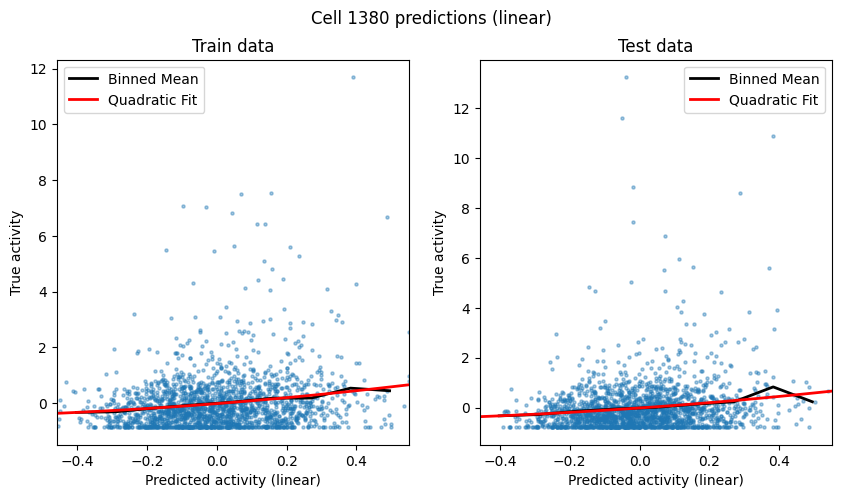

In [47]:
# plot pred_train on x vs Y_train on y for a random cell
# (1 plot for train on left, 1 plot for test on right)
rand_cell = rng.integers(0, n_target_cells)
x_min, x_max = np.percentile(pred_train[rand_cell, :], [0.5, 99.5])
y_min, y_max = np.percentile(Y_train[rand_cell, :], [0.5, 99.5])

plt.figure(figsize=(10, 5))
# get binned mean to plot the quadratic fit
bins = np.linspace(x_min, x_max, 10)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
digitized = np.digitize(pred_train[rand_cell, :], bins)
bin_means_train = [Y_train[rand_cell, :][digitized == i].mean() for i in range(1, len(bins))]
digitized = np.digitize(pred_test[rand_cell, :], bins)
bin_means_test = [Y_test[rand_cell, :][digitized == i].mean() for i in range(1, len(bins))]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pred_train[rand_cell, :], Y_train[rand_cell, :], alpha=0.4, s=5)
# plot binned means
plt.plot(bin_centers, bin_means_train, color='black', linewidth=2, label='Binned Mean')
# plot quadratic fit
x_fit = np.linspace(x_min, x_max, 100)
y_fit = np.polyval(quad_coeffs[rand_cell, :], x_fit)
plt.plot(x_fit, y_fit, color='red', linestyle='-', linewidth=2, label='Quadratic Fit')
plt.xlim(x_min, x_max)
plt.legend()
plt.xlabel("Predicted activity (linear)")
plt.ylabel("True activity")
plt.title("Train data")

plt.subplot(1, 2, 2)
plt.scatter(pred_test[rand_cell, :], Y_test[rand_cell, :], alpha=0.4, s=5)
plt.plot(bin_centers, bin_means_test, color='black', linewidth=2, label='Binned Mean')
# plot quadratic fit
x_fit = np.linspace(x_min, x_max, 100)
y_fit = np.polyval(quad_coeffs[rand_cell, :], x_fit)
plt.plot(x_fit, y_fit, color='red', linestyle='-', linewidth=2, label='Quadratic Fit')
plt.legend()
plt.xlim(x_min, x_max)
plt.xlabel("Predicted activity (linear)")
plt.ylabel("True activity")
plt.title("Test data")
plt.suptitle(f"Cell {rand_cell} predictions (linear)")
plt.show()

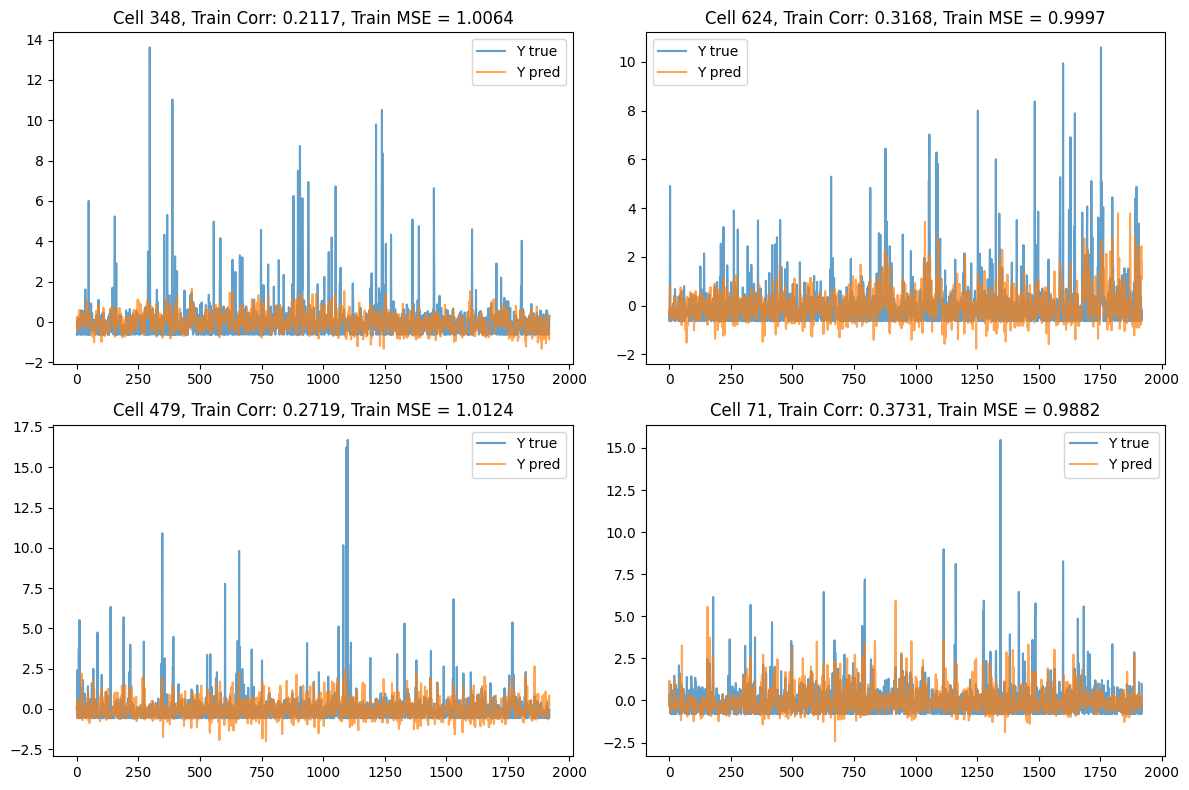

In [60]:
# plot Y_pred_train against Y_train for 4 example cells
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
example_cells = np.random.choice(Y[0].shape[0], size=4, replace=False)
for ax, cell_idx in zip(axs.flatten(), example_cells):
    ax.plot(Y[0][cell_idx], label="Y true", alpha=0.7)
    ax.plot(Y_pred_train[cell_idx], label="Y pred", alpha=0.7)
    ax.set_title(f"Cell {cell_idx}, Train Corr: {np.corrcoef(Y[0][cell_idx], Y_pred_train[cell_idx])[0,1]:.4f}, Train MSE = {np.mean((Y[0][cell_idx] - Y_pred_train[cell_idx])**2):.4f}")
    ax.legend()
plt.tight_layout()
plt.show()

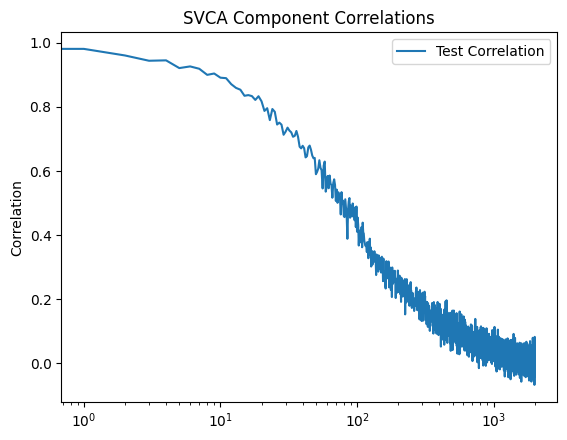

In [37]:
# compute correlation of each vca component on x and y for train
# plt.plot(corr_train, label='Train Correlation')
plt.plot(corr_test, label='Test Correlation')
plt.xscale('log')
plt.ylabel('Correlation')
plt.title('SVCA Component Correlations')
plt.legend()
plt.show()

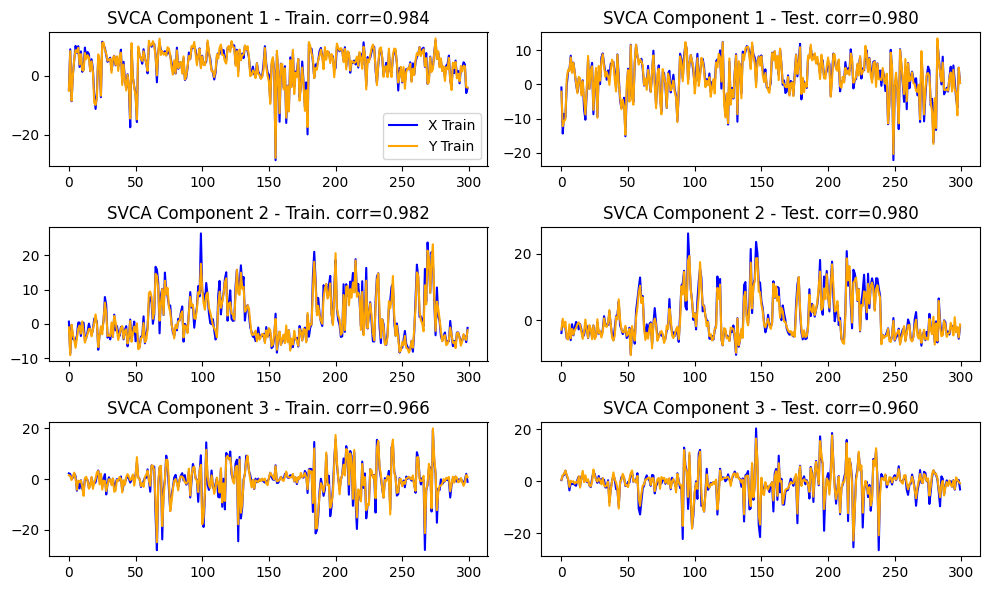

In [10]:
# plot 
k_plot = 3
plt.figure(figsize=(10, 6))
T_min, T_max = 0, 300
for i in range(k_plot):
    plt.subplot(k_plot, 2, 2 * i + 1)
    plt.plot(U_train[i, T_min:T_max], color='blue', label='X Train')
    plt.plot(V_train[i, T_min:T_max], color='orange', label='Y Train')
    plt.title(f'SVCA Component {i+1} - Train. corr={corr_train[i]:.3f}')
    if i == 0:
        plt.legend()
    plt.subplot(k_plot, 2, 2 * i + 2)
    plt.plot(U_test[i, T_min:T_max], color='blue', label='X Test')
    plt.plot(V_test[i, T_min:T_max], color='orange', label='Y Test')
    plt.title(f'SVCA Component {i+1} - Test. corr={corr_test[i]:.3f}')
plt.tight_layout()
plt.show()

In [41]:
# take top k components and then reconstruct Y and X from these
k_top = 10
X_tilde_train = Wx[:, :k_top].T @ X[0]  # k x n_time
Y_tilde_train = Wy[:, :k_top].T @ Y[0]  # k x n_time
X_tilde_test = Wx[:, :k_top].T @ X[1]  # k x n_time
Y_tilde_test = Wy[:, :k_top].T @ Y[1]  # k x n_time

In [42]:
def moving_std(x, window=10):
    """Centered moving std with edge handling."""
    x = np.asarray(x)
    T = x.shape[0]
    hw = window // 2
    out = np.empty_like(x, dtype=float)
    for t in range(T):
        lo = max(0, t - hw)
        hi = min(T, t + hw + 1)
        out[t] = np.std(x[lo:hi])
    return out

def embed_umap_and_transform(X_tilde_train, Y_tilde_train, X_tilde_test, Y_tilde_test,
                            n_neighbors=30, seed=0):
    reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, random_state=seed)
    X_train_emb = reducer.fit_transform(X_tilde_train.T)      # (T_train, 2)
    Y_train_emb = reducer.transform(Y_tilde_train.T)          # (T_train, 2)
    X_test_emb  = reducer.transform(X_tilde_test.T)           # (T_test, 2)
    Y_test_emb  = reducer.transform(Y_tilde_test.T)           # (T_test, 2)
    return reducer, X_train_emb, Y_train_emb, X_test_emb, Y_test_emb

def plot_4panel_embeddings(X_train_emb, Y_train_emb, X_test_emb, Y_test_emb,
                           colour_train, colour_test, name=""):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

    def sc(ax, Z, c, title):
        h = ax.scatter(Z[:, 0], Z[:, 1], c=c, s=5, alpha=0.5)
        fig.colorbar(h, ax=ax)
        ax.set_title(title)
        ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

    sc(axs[0, 0], X_train_emb, colour_train, f"X_train colored by {name}")
    sc(axs[0, 1], Y_train_emb, colour_train, f"Y_train colored by {name}")
    sc(axs[1, 0], X_test_emb,  colour_test,  f"X_test colored by {name}")
    sc(axs[1, 1], Y_test_emb,  colour_test,  f"Y_test colored by {name}")

    plt.show()

In [ ]:
# noise_std = np.sqrt(noise_var_conditional_diff(spks - spks.mean(axis=1, keepdims=True), p=0.2, min_samples=10))
# spks_whitened = (spks - spks.mean(axis=1, keepdims=True)) / (noise_std[:, np.newaxis] + EPS)
# # plot  noise std vs concentration
# noise_var_white = noise_var_conditional_diff(spks_whitened)
# noise_std_white = np.sqrt(noise_var_white)
# plt.figure(figsize=(6, 4))
# plt.scatter(conc, noise_std_white, alpha=0.5, s=10)
# plt.xlim([-0.05, 1.05])
# plt.yscale("log")
# plt.xlabel("Concentration Metric")
# plt.ylabel("Noise std (log scale)")
# plt.title("spikes whitened")
# plt.grid(True)
# plt.show()
# # Time split
# spks = spks_whitened
# T = spks.shape[1]
# train_t, test_t = make_time_split(T, BLOCK_SIZE, TRAIN_TEST_SPLIT)
# # Cell split
# train_cells, test_cells = split_cells(N_CELLS, rng)
# X, Y = make_XY(spks, train_cells, test_cells, train_t, test_t)

In [10]:
# # predict subsqeuent timepoints from previous using a linear model
# X_train = X[0]
# # we want X[c, t+1] = b + W_1 @ X[c, t] + W_2 X[c, t] ** 2 + 
# # X_t0_train = np.vstack([X_train[:, :-1], X_train[:, :-1] ** 2])
# # X_t1_train = X_train[:, 1:]
# X_t0_train = X_train[:, :-1]
# X_t1_train = X_train[:, 1:]
# # fit PLS
# k = 8
# pls = PLSRegression(n_components=k)
# pls.fit(X_t0_train.T, X_t1_train.T)
# # predict on train
# X_t1_train_pred_pls = pls.predict(X_t0_train.T).T
# # report mse and corr on train and test
# # X_t0_test = np.vstack([X[1][:, :-1], X[1][:, :-1] ** 2])
# # X_t1_test = X[1][:, 1:]
# X_t0_test = X[1][:, :-1]
# X_t1_test = X[1][:, 1:]
# X_t1_test_pred_pls = pls.predict(X_t0_test.T).T
# train_mse_pls = mse(X_t1_train, X_t1_train_pred_pls)
# test_mse_pls = mse(X_t1_test, X_t1_test_pred_pls)
# train_corr_pls = mean_row_corr(X_t1_train, X_t1_train_pred_pls, eps=EPS)
# test_corr_pls = mean_row_corr(X_t1_test, X_t1_test_pred_pls, eps=EPS)
# print(f"PLS Regression (K={k}):")
# print(f"  Train MSE: {train_mse_pls:.4f}, Train Corr: {train_corr_pls:.4f}")
# print(f"  Test MSE: {test_mse_pls:.4f}, Test Corr: {test_corr_pls:.4f}")

In [11]:
# predict Y[0] from X[0] using PLS and ridge regression.
from typing import Optional
# PLS solver controls (runtime + convergence)
PLS_MAX_ITER = 500
PLS_TOL = 1e-5

class PLSRidge():
    def __init__(self, k: int = 16, alpha: float = 100.0, max_iter: Optional[int] = None, tol: Optional[float] = None):
        self.k = int(k)
        self.alpha = float(alpha)
        max_iter = PLS_MAX_ITER if max_iter is None else int(max_iter)
        tol = PLS_TOL if tol is None else float(tol)
        self.max_iter = int(min(max_iter, PLS_MAX_ITER))
        self.tol = float(max(tol, PLS_TOL))
        self.pls = None
        self.ridge = None

    def fit(self, Xtr, Ytr):
        X = Xtr.T
        Y = Ytr.T
        self.pls = PLSRegression(n_components=self.k, scale=False, max_iter=self.max_iter, tol=self.tol)
        Z = self.pls.fit_transform(X, Y)[0]
        self.ridge = Ridge(alpha=self.alpha, fit_intercept=True)
        self.ridge.fit(Z, Y)
        return self

    def predict(self, Xte):
        X = Xte.T
        Z = self.pls.transform(X)
        Yhat = self.ridge.predict(Z)
        return Yhat.T
    
plsridge = PLSRidge(k=64, alpha=1.0)
plsridge.fit(X[0], Y[0])
Y_train_pred_plsridge = plsridge.predict(X[0])
Y_test_pred_plsridge = plsridge.predict(X[1])
train_mse_plsridge = mse(Y[0], Y_train_pred_plsridge)
test_mse_plsridge = mse(Y[1], Y_test_pred_plsridge)
train_corr_plsridge = mean_row_corr(Y[0], Y_train_pred_plsridge, eps=EPS)
test_corr_plsridge = mean_row_corr(Y[1], Y_test_pred_plsridge, eps=EPS)
# get variance explained
train_r2_plsridge = var_explained(Y[0], Y_train_pred_plsridge, eps=EPS)
test_r2_plsridge = var_explained(Y[1], Y_test_pred_plsridge, eps=EPS)
print(f"PLS + Ridge Regression (K={plsridge.k}, alpha={plsridge.alpha}):")
print(f"  Train MSE: {train_mse_plsridge:.4f}, Train Corr: {train_corr_plsridge:.4f}, Train R^2: {train_r2_plsridge:.4f}")
print(f"  Test MSE: {test_mse_plsridge:.4f}, Test Corr: {test_corr_plsridge:.4f}, Test R^2: {test_r2_plsridge:.4f}")

PLS + Ridge Regression (K=64, alpha=1.0):
  Train MSE: 0.7992, Train Corr: 0.4149, Train R^2: 0.1947
  Test MSE: 0.9013, Test Corr: 0.2931, Test R^2: 0.1058


In [12]:
# fit pls model followed by a cell specific quadratic nonlinearity
coeffs = np.zeros((Y.shape[1], 3))  # for each test cell, store [a, b, c] for ax^2 + bx + c
from numpy.polynomial import Polynomial
Y_test_pred_pls_nl = np.zeros_like(Y[1])
for i in range(Y.shape[1]):
    # fit quadratic to Y_train_pred_pls
    p = Polynomial.fit(x=Y_train_pred_plsridge[i], y=Y[0][i], deg=2)
    coeffs[i, :] = p.convert().coef  # store coefficients
    Y_test_pred_pls_nl[i] = p(Y_test_pred_plsridge[i])
# compute train and test mse and corr
train_mse_pls_nl = mse(Y[0], Y_train_pred_plsridge)
test_mse_pls_nl = mse(Y[1], Y_test_pred_pls_nl)
train_corr_pls_nl = mean_row_corr(Y[0], Y_train_pred_plsridge, eps=EPS)
test_corr_pls_nl = mean_row_corr(Y[1], Y_test_pred_pls_nl, eps=EPS)
train_r2_pls_nl = var_explained(Y[0], Y_train_pred_plsridge, eps=EPS)
test_r2_pls_nl = var_explained(Y[1], Y_test_pred_pls_nl, eps=EPS)

print(f"PLS + Ridge + Quadratic Nonlinearity:")
print(f"  Train MSE: {train_mse_pls_nl:.4f}, Train Corr: {train_corr_pls_nl:.4f}, Train R^2: {train_r2_pls_nl:.4f}")
print(f"  Test MSE: {test_mse_pls_nl:.4f}, Test Corr: {test_corr_pls_nl:.4f}, Test R^2: {test_r2_pls_nl:.4f}")

PLS + Ridge + Quadratic Nonlinearity:
  Train MSE: 0.7992, Train Corr: 0.4149, Train R^2: 0.1947
  Test MSE: 0.8861, Test Corr: 0.3163, Test R^2: 0.1221


In [141]:
# fit pls followed by an exponential nonlinearity
Y_test_pred_pls_exp = np.zeros_like(Y[1])
for i in range(Y.shape[1]):
    # fit exponential to Y_train_pred_pls
    from scipy.optimize import curve_fit

    def exp_func(x, a, b):
        return a * np.exp(b * x)

    # fit exponential
    popt, _ = curve_fit(exp_func, Y_train_pred_plsridge[i], Y[0][i], p0=(1.0, 0.1), maxfev=10000)
    Y_test_pred_pls_exp[i] = exp_func(Y_test_pred_plsridge[i], *popt)
# compute train and test mse and corr
train_mse_pls_exp = mse(Y[0], Y_train_pred_plsridge)
test_mse_pls_exp = mse(Y[1], Y_test_pred_pls_exp)
train_corr_pls_exp = mean_row_corr(Y[0], Y_train_pred_plsridge, eps=EPS)
test_corr_pls_exp = mean_row_corr(Y[1], Y_test_pred_pls_exp, eps=EPS)
train_r2_pls_exp = var_explained(Y[0], Y_train_pred_plsridge, eps=EPS)
test_r2_pls_exp = var_explained(Y[1], Y_test_pred_pls_exp, eps=EPS)
print(f"PLS + Ridge + Exponential Nonlinearity:")
print(f"  Train MSE: {train_mse_pls_exp:.4f}, Train Corr: {train_corr_pls_exp:.4f}, Train R^2: {train_r2_pls_exp:.4f}")
print(f"  Test MSE: {test_mse_pls_exp:.4f}, Test Corr: {test_corr_pls_exp:.4f}, Test R^2: {test_r2_pls_exp:.4f}")

n_bins = 10
# assume Y[split] is (n_cells, T)
n_cells = Y[0].shape[0]
cell_idx = np.random.randint(n_cells)

x_train = Y_train_pred_plsridge[cell_idx]
x_test  = Y_test_pred_plsridge[cell_idx]
y_train = Y[0][cell_idx]
y_test  = Y[1][cell_idx]

def binned_mean(x, y, n_bins=10, lo=1, hi=99):
    edges = np.linspace(np.percentile(x, lo), np.percentile(x, hi), n_bins + 1)
    idx = np.digitize(x, edges)  # bins 1..n_bins+1 (rightmost can overflow)
    centers = 0.5 * (edges[:-1] + edges[1:])
    means = np.array([np.nanmean(y[idx == k]) if np.any(idx == k) else np.nan
                      for k in range(1, n_bins + 1)])
    return centers, means, edges

cent_tr, mean_tr, edges_tr = binned_mean(x_train, y_train, n_bins)
cent_te, mean_te, edges_te = binned_mean(x_test,  y_test,  n_bins)

# quadratic
x_fit = np.linspace(np.percentile(x_train, 1), np.percentile(x_train, 99), 200)
a, b, c = coeffs[cell_idx]
y_fit = a * x_fit**2 + b * x_fit + c
xmin, xmax = min(np.percentile(x_train, 1), np.percentile(x_test, 1)), max(np.percentile(x_train, 99), np.percentile(x_test, 99))
ymin, ymax = min(np.percentile(y_train, 1), np.percentile(y_test, 1)), max(np.percentile(y_train, 99), np.percentile(y_test, 99))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(x_train, y_train, s=5, alpha=0.1)
plt.plot(cent_tr, mean_tr, marker='o')
plt.plot(x_fit, y_fit, lw=2)
plt.title(f"Train cell {cell_idx}")
plt.xlabel("Linear prediction")
plt.ylabel("True activity")
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(x_test, y_test, s=5, alpha=0.1)
plt.plot(cent_te, mean_te, marker='o')
# (optionally refit quadratic on test if that's what you want; otherwise reuse)
plt.plot(x_fit, y_fit, lw=2)
plt.title(f"Test cell {cell_idx}")
plt.xlabel("Linear prediction")
plt.ylabel("True activity")
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.grid(True)

plt.tight_layout()
plt.show()


PLS + Ridge + Exponential Nonlinearity:
  Train MSE: 0.7992, Train Corr: 0.4149, Train R^2: 0.1947
  Test MSE: 0.9627, Test Corr: 0.2595, Test R^2: 0.0645


In [157]:
np.sum(run_speed == 0)

np.int64(971)

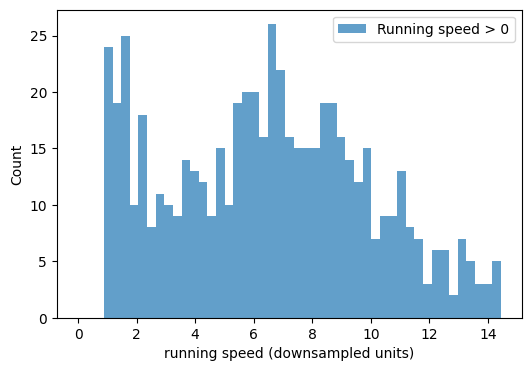

In [160]:
plt.figure(figsize=(6, 4))
plt.hist(run_speed[run_speed > 1], bins=np.linspace(0, np.percentile(run_speed, 99), 50), alpha=0.7, label='Running speed > 0')
plt.xlabel('running speed (downsampled units)')
plt.ylabel('Count')
# plt.xscale('log')
plt.legend()
plt.show()

Fitted nonlinearity for 2000 / 2000 cells successfully.


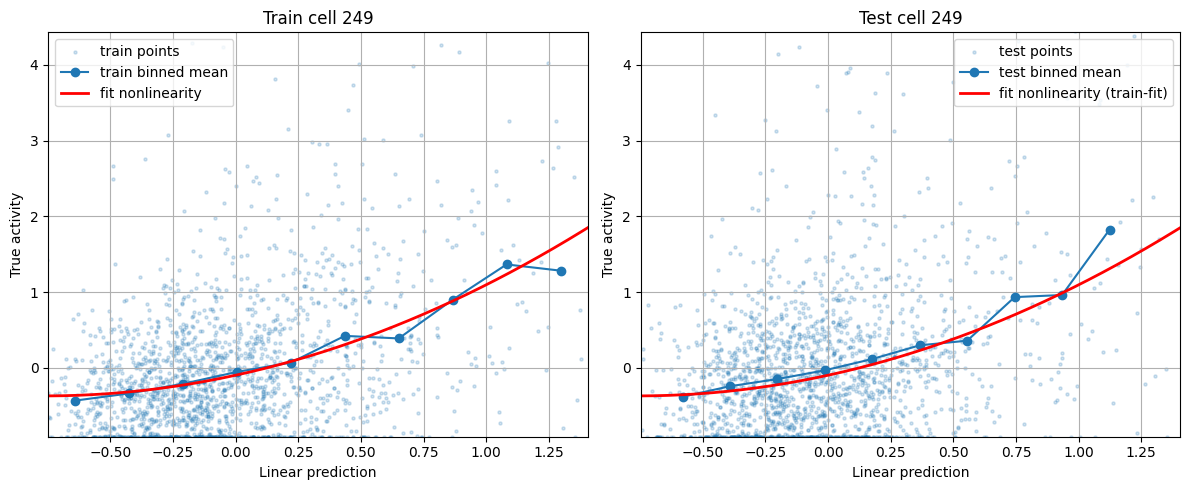

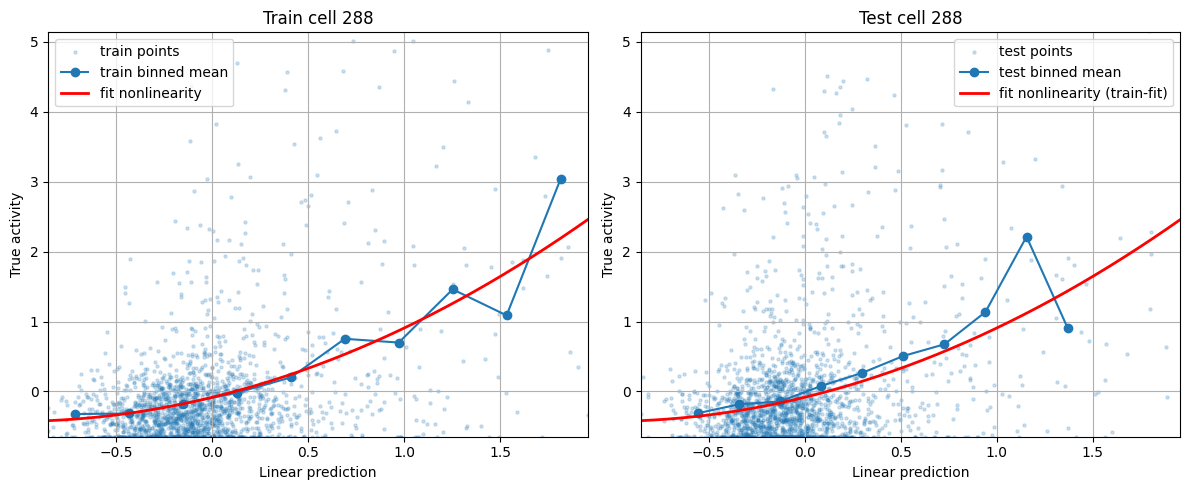

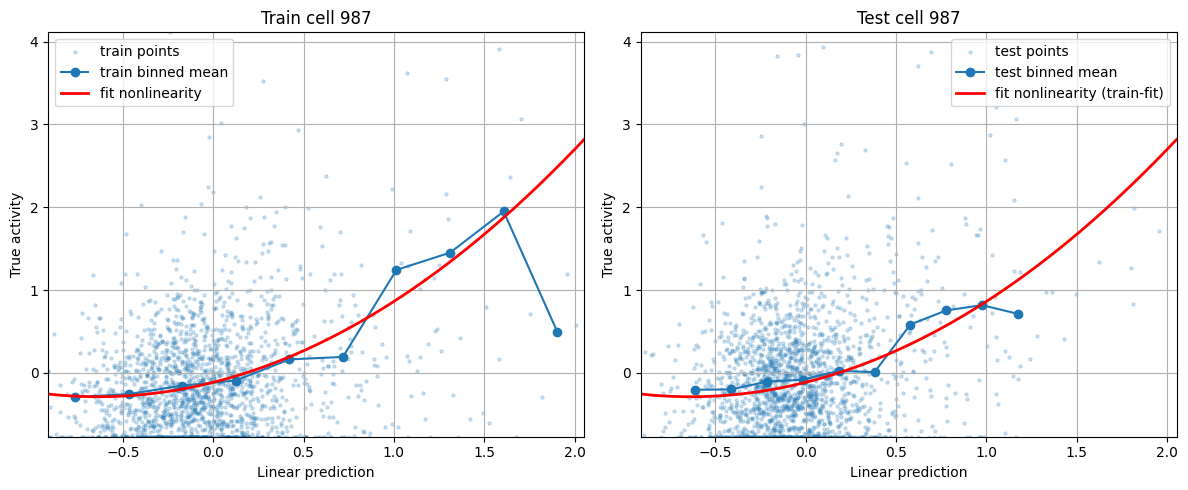

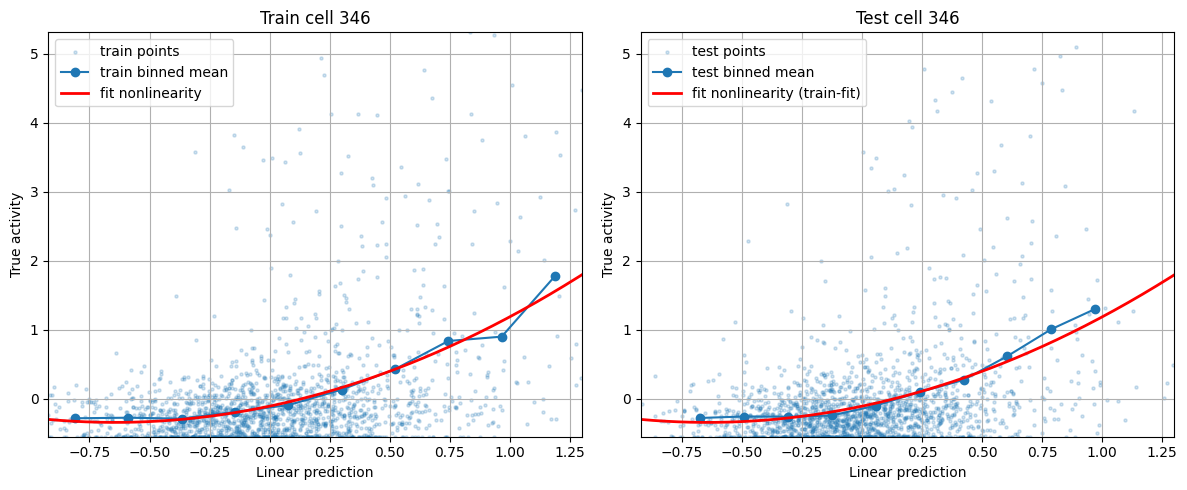

{'train_MSE': 0.7570440562068981, 'test_MSE': 0.8860926635369951, 'train_Corr': 0.4760312813932252, 'test_Corr': 0.33891511392352125, 'train_R2': 0.23615553481258908, 'test_R2': 0.12022435202743859}


In [163]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit_nonlinearity_and_eval(
    Y_train_pred, Y_test_pred, Y_train, Y_test,
    nonlin, p0, bounds=(-np.inf, np.inf),
    metrics=None,
    n_plot=6, n_bins=10, lo=1, hi=99,
    maxfev=20000, seed=0
):
    """
    Fit the SAME parametric nonlinearity per cell on training data:
        y_hat = nonlin(x, *theta_i)
    then apply to both train/test, report metrics, and plot example cells.

    Shapes: all arrays are (n_cells, T).
      Y_train_pred: linear predictions on train
      Y_test_pred : linear predictions on test
      Y_train     : true targets on train
      Y_test      : true targets on test

    nonlin: callable f(x, *params) -> y
    p0: tuple/list initial params for curve_fit (or callable p0(x,y)->p0)
    bounds: curve_fit bounds
    metrics: dict of name -> fn(y_true, y_pred) returning scalar.
             If None, uses MSE, mean row corr, and var explained.
    """
    rng = np.random.default_rng(seed)

    # default metrics
    # --------------------
    def mse(a, b): return float(np.mean((a - b) ** 2))

    def mean_row_corr(a, b, eps=1e-12):
        a0 = a - a.mean(axis=1, keepdims=True)
        b0 = b - b.mean(axis=1, keepdims=True)
        num = np.sum(a0 * b0, axis=1)
        den = np.sqrt(np.sum(a0**2, axis=1) * np.sum(b0**2, axis=1)) + eps
        return float(np.mean(num / den))

    def var_explained(a, b, eps=1e-12):
        num = np.sum((a - b) ** 2, axis=1)
        den = np.sum((a - a.mean(axis=1, keepdims=True)) ** 2, axis=1) + eps
        return float(np.mean(1.0 - num / den))

    if metrics is None:
        metrics = {"MSE": mse, "Corr": mean_row_corr, "R2": var_explained}

    # --------------------
    # fit per cell on train
    # --------------------
    P = None
    p_dim = None
    params = []
    bad = np.zeros(n_cells, dtype=bool)

    Yhat_train = np.empty_like(Y_train, dtype=float)
    Yhat_test  = np.empty_like(Y_test, dtype=float)

    for i in range(n_cells):
        xtr = np.asarray(Y_train_pred[i], float)
        ytr = np.asarray(Y_train[i], float)

        # choose init
        p0_i = p0(xtr, ytr) if callable(p0) else p0

        # fit (robustify by finite mask)
        m = np.isfinite(xtr) & np.isfinite(ytr)
        if m.sum() < 5:
            bad[i] = True
            params.append(None)
            Yhat_train[i] = np.nan
            Yhat_test[i] = np.nan
            continue

        try:
            popt, _ = curve_fit(
                nonlin, xtr[m], ytr[m],
                p0=p0_i, bounds=bounds, maxfev=maxfev
            )
            if p_dim is None:
                p_dim = len(popt)
            params.append(popt)
            Yhat_train[i] = nonlin(Y_train_pred[i], *popt)
            Yhat_test[i]  = nonlin(Y_test_pred[i],  *popt)
        except Exception:
            bad[i] = True
            params.append(None)
            Yhat_train[i] = np.nan
            Yhat_test[i] = np.nan

    # --------------------
    # metrics (ignore bad cells)
    # --------------------
    good = ~bad & np.isfinite(Yhat_train).all(axis=1) & np.isfinite(Yhat_test).all(axis=1)
    print(f"Fitted nonlinearity for {good.sum()} / {n_cells} cells successfully.")
    if not np.any(good):
        raise RuntimeError("All cells failed nonlinearity fit.")

    Ytr_g, Yte_g = Y_train[good], Y_test[good]
    Yhtr_g, Yhte_g = Yhat_train[good], Yhat_test[good]

    report = {}
    for name, fn in metrics.items():
        report[f"train_{name}"] = fn(Ytr_g, Yhtr_g)
        report[f"test_{name}"]  = fn(Yte_g, Yhte_g)

    # --------------------
    # plotting helpers
    # --------------------
    def binned_mean(x, y, n_bins=10, lo=1, hi=99):
        edges = np.linspace(np.percentile(x, lo), np.percentile(x, hi), n_bins + 1)
        idx = np.digitize(x, edges)
        centers = 0.5 * (edges[:-1] + edges[1:])
        means = np.array([np.nanmean(y[idx == k]) if np.any(idx == k) else np.nan
                          for k in range(1, n_bins + 1)])
        return centers, means, edges

    # choose example cells from good fits
    ex_cells = np.random.choice(np.where(good)[0], size=min(n_plot, good.sum()), replace=False)

    for cell_idx in ex_cells:
        xtr = Y_train_pred[cell_idx]
        xte = Y_test_pred[cell_idx]
        ytr = Y_train[cell_idx]
        yte = Y_test[cell_idx]
        popt = params[cell_idx]

        cent_tr, mean_tr, _ = binned_mean(xtr, ytr, n_bins, lo, hi)
        cent_te, mean_te, _ = binned_mean(xte, yte, n_bins, lo, hi)

        xmin = min(np.percentile(xtr, lo), np.percentile(xte, lo))
        xmax = max(np.percentile(xtr, hi), np.percentile(xte, hi))
        x_fit = np.linspace(xmin, xmax, 300)
        y_fit = nonlin(x_fit, *popt)

        ymin = min(np.percentile(ytr, lo), np.percentile(yte, lo))
        ymax = max(np.percentile(ytr, hi), np.percentile(yte, hi))

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.scatter(xtr, ytr, s=5, alpha=0.2, label="train points")
        plt.plot(cent_tr, mean_tr, marker="o", linestyle="-", label="train binned mean")
        plt.plot(x_fit, y_fit, lw=2, color="red", label="fit nonlinearity")
        plt.title(f"Train cell {cell_idx}")
        plt.xlabel("Linear prediction")
        plt.ylabel("True activity")
        plt.xlim(xmin, xmax)
        plt.ylim(ymin, ymax)
        plt.grid(True)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.scatter(xte, yte, s=5, alpha=0.2, label="test points")
        plt.plot(cent_te, mean_te, marker="o", linestyle="-", label="test binned mean")
        plt.plot(x_fit, y_fit, lw=2, color="red", label="fit nonlinearity (train-fit)")
        plt.title(f"Test cell {cell_idx}")
        plt.xlabel("Linear prediction")
        plt.ylabel("True activity")
        plt.xlim(xmin, xmax)
        plt.ylim(ymin, ymax)
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

    return {
        "params": params,
        "good_mask": good,
        "Yhat_train": Yhat_train,
        "Yhat_test": Yhat_test,
        "report": report,
    }


# -------------------------
# Example: quad nonlinearity
# -------------------------
def quad_func(x, a, b, c):
    return a * x**2 + b * x + c

# Call like:
out = fit_nonlinearity_and_eval(
    Y_train_pred_plsridge, Y_test_pred_plsridge, Y[0], Y[1],
    nonlin=quad_func,
    p0=(0.0, 1.0, 0.0),
    bounds=([0.0, -np.inf, -np.inf], [np.inf, np.inf, np.inf]),   # optional
    n_plot=4
)
print(out["report"])


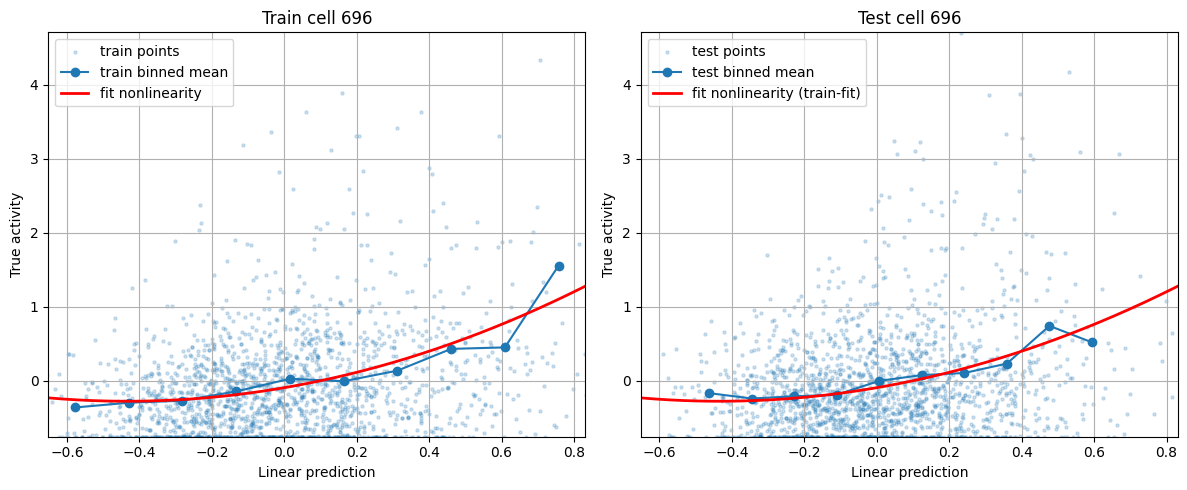

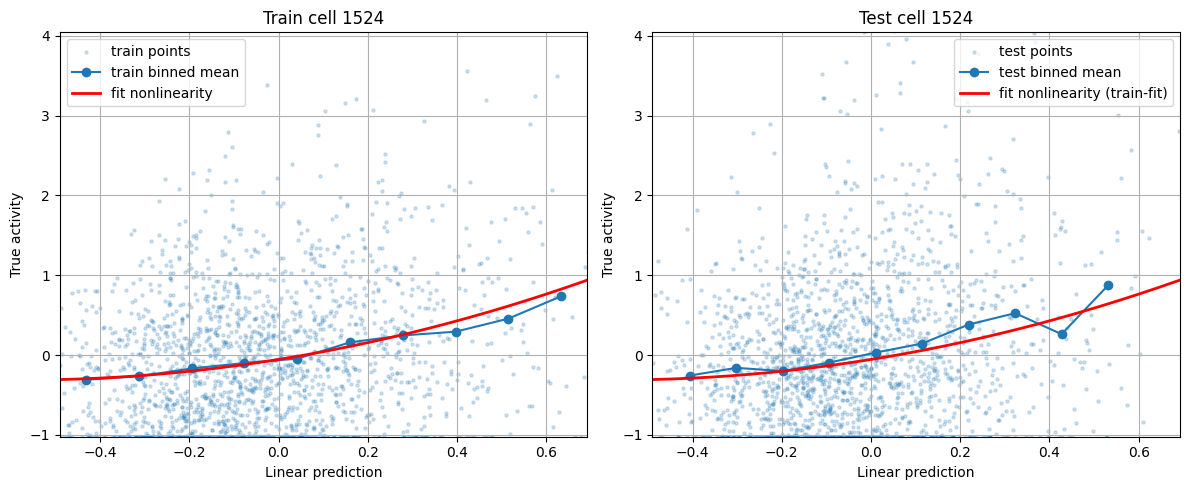

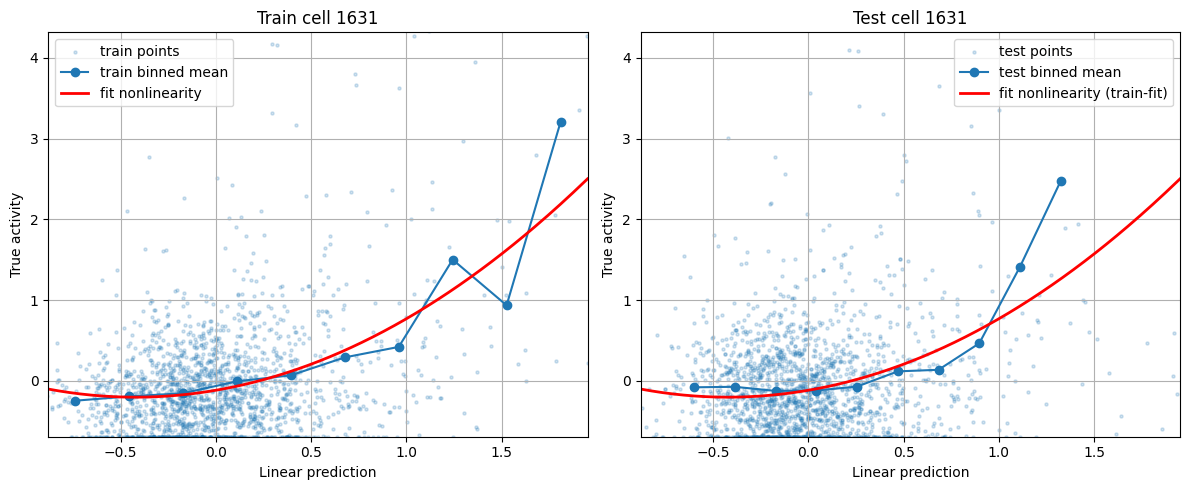

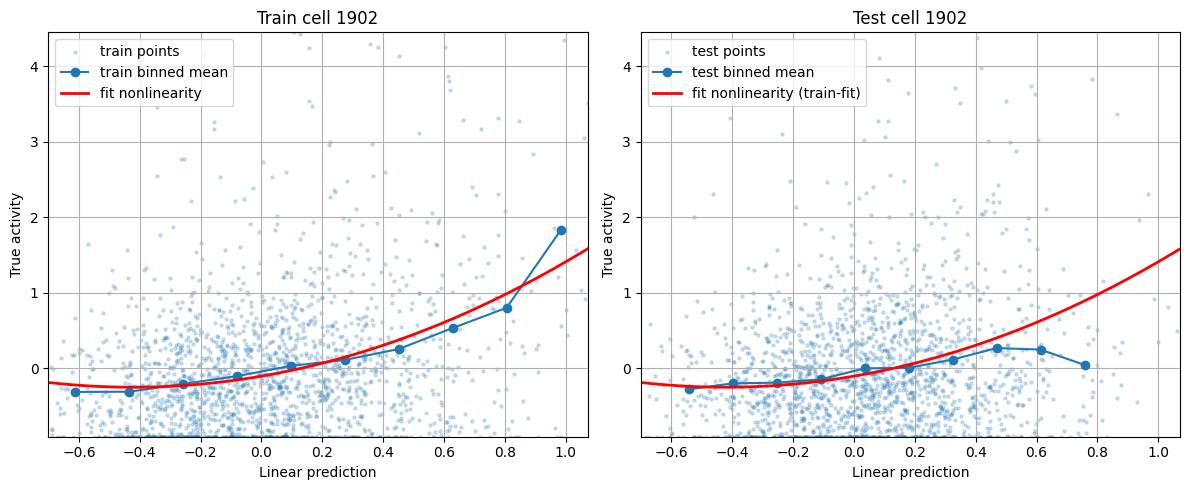

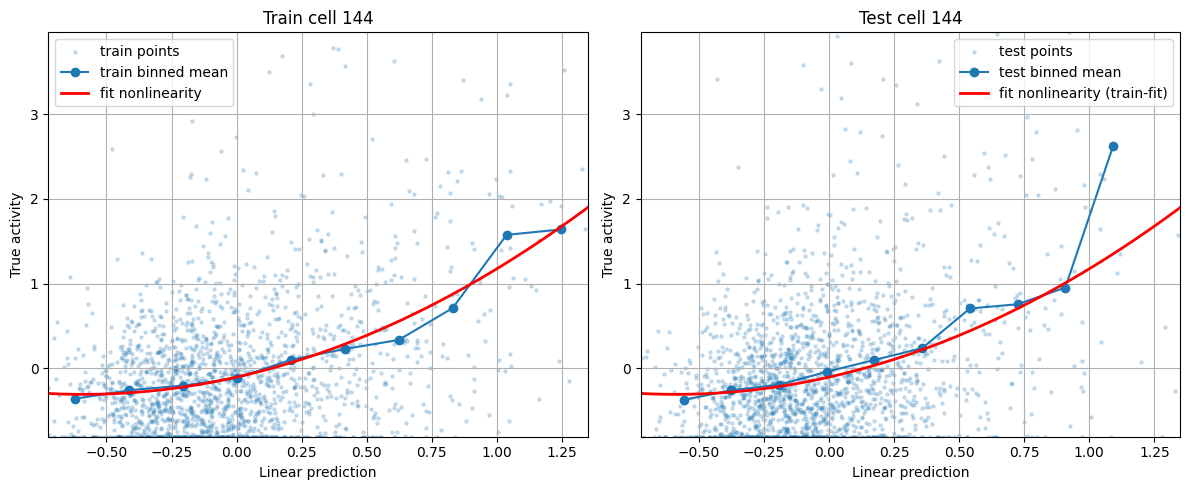

In [699]:
yhat_train_ln = Y_train_pred_plsridge
yhat_train_quad = out["Yhat_train"]
yhat_test_ln = Y_test_pred_plsridge
yhat_test_quad = out["Yhat_test"]

# choose cells and plot linear vs true predictions
n_plot = 5
lo, hi = 1, 99
n_bins = 10

# --------------------
# plotting helpers
# --------------------
def binned_mean(x, y, n_bins=10, lo=1, hi=99):
    edges = np.linspace(np.percentile(x, lo), np.percentile(x, hi), n_bins + 1)
    idx = np.digitize(x, edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    means = np.array([np.nanmean(y[idx == k]) if np.any(idx == k) else np.nan
                        for k in range(1, n_bins + 1)])
    return centers, means, edges

# choose example cells from good fits
ex_cells = np.random.choice(Y.shape[1], size=n_plot, replace=False)

for cell_idx in ex_cells:
    xtr = yhat_train_ln[cell_idx]
    xte = yhat_test_ln[cell_idx]
    ytr = Y[0][cell_idx]
    yte = Y[1][cell_idx]
    popt = out["params"][cell_idx]

    cent_tr, mean_tr, _ = binned_mean(xtr, ytr, n_bins, lo, hi)
    cent_te, mean_te, _ = binned_mean(xte, yte, n_bins, lo, hi)

    xmin = min(np.percentile(xtr, lo), np.percentile(xte, lo))
    xmax = max(np.percentile(xtr, hi), np.percentile(xte, hi))
    x_fit = np.linspace(xmin, xmax, 300)
    y_fit = quad_func(x_fit, *popt)

    ymin = min(np.percentile(ytr, lo), np.percentile(yte, lo))
    ymax = max(np.percentile(ytr, hi), np.percentile(yte, hi))

    run_speed_tr = run_speed[train_t]
    run_speed_te = run_speed[test_t]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(xtr, ytr, s=5, alpha=0.2, label="train points")
    # plt.scatter(xtr, ytr, s=5, alpha=np.clip(run_speed_tr / (np.percentile(run_speed_tr, 99) + 1e-6), 0, 1), label="train points", c=run_speed_tr)
    plt.plot(cent_tr, mean_tr, marker="o", linestyle="-", label="train binned mean")
    plt.plot(x_fit, y_fit, lw=2, color="red", label="fit nonlinearity")
    plt.title(f"Train cell {cell_idx}")
    plt.xlabel("Linear prediction")
    plt.ylabel("True activity")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(xte, yte, s=5, alpha=0.2, label="test points")
    # plt.scatter(xte, yte, s=5, alpha=np.clip(run_speed_te / (np.percentile(run_speed_te, 99) + 1e-6), 0, 1), label="test points", c=run_speed_te)
    plt.plot(cent_te, mean_te, marker="o", linestyle="-", label="test binned mean")
    plt.plot(x_fit, y_fit, lw=2, color="red", label="fit nonlinearity (train-fit)")
    plt.title(f"Test cell {cell_idx}")
    plt.xlabel("Linear prediction")
    plt.ylabel("True activity")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


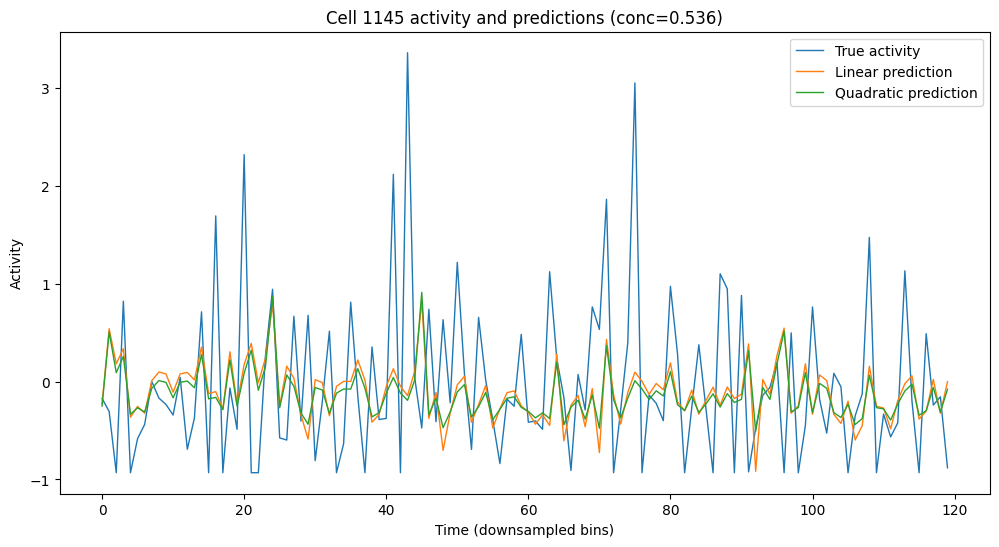

In [687]:
# choose a random test cell, plot its activity and the predictions from linear and quadratic models
n_cells = Y.shape[1]
cell_idx = np.random.randint(n_cells)
T_min, T_max = 0, 120
plt.figure(figsize=(12, 6))
plt.plot(Y[1][cell_idx, T_min:T_max], label='True activity', lw=1)
plt.plot(yhat_test_ln[cell_idx, T_min:T_max], label='Linear prediction', lw=1)
plt.plot(yhat_test_quad[cell_idx, T_min:T_max], label='Quadratic prediction', lw=1)
plt.xlabel('Time (downsampled bins)')
plt.ylabel('Activity')
plt.title(f'Cell {cell_idx} activity and predictions (conc={conc[test_cells[cell_idx]]:.3f})')
plt.legend()
# plt.grid(True)
plt.show()

In [712]:
# try apply nonlinearity to (linear prediction, run_speed) to predict true activity
import tqdm
from scipy.optimize import curve_fit

def quad_func_2d(x, r, A, b, c):
    """
    quadratic form in two variables:
    qf(x, r) = (x, r)^T @ A @ (x, r) + b^T @ (x, r) + c
    where A is a 2x2 symmetric matrix, b is a 2D vector, c is a scalar.
    Parameters
    ----------
    x : array-like, shape (n_samples,)
        First input variable.
    r : array-like, shape (n_samples,)
        Second input variable.
    A : array-like, shape (3,)
        Symmetric matrix parameters [A11, A12, A22].
    b : array-like, shape (2,)
        Linear coefficients [b1, b2].
    c : float
        Constant term.
    """
    z = np.vstack([x, r])  # shape (2, n_samples)
    A_mat = np.array([[A[0], A[1]], [A[1], A[2]]])  # shape (2, 2)
    quad_term = np.einsum('ij,jk,ik->i', z.T, A_mat, z.T)  # shape (n_samples,)
    lin_term = b[0] * x + b[1] * r  # shape (n_samples,)
    return quad_term + lin_term + c

# optimize params
p0 = ([0, 0, 0], [1, 0], 0)  # A: zero, b: [1,0], c:0
p0_flat = np.concatenate([p0[0], p0[1], [p0[2]]])
def quad_func_2d_flat(xr, A11, A12, A22, b1, b2, c):
    x, r = xr
    return quad_func_2d(x, r, [A11, A12, A22], [b1, b2], c)
yhat_train_2d = np.zeros_like(Y[0])
yhat_test_2d = np.zeros_like(Y[1])

for c in tqdm.tqdm(range(Y.shape[1])):
    xtr = yhat_train_ln[c]
    xte = yhat_test_ln[c]
    rtr = run_speed[train_t]
    rte = run_speed[test_t]
    ytr = Y[0][c]
    yte = Y[1][c]
    popt, _ = curve_fit(
        quad_func_2d_flat,
        (xtr, rtr),
        ytr,
        p0=p0_flat,
        maxfev=20000
    )
    # predict
    yhat_train_2d[c] = quad_func_2d_flat((xtr, rtr), *popt)
    yhat_test_2d[c] = quad_func_2d_flat((xte, rte), *popt)

100%|██████████| 2000/2000 [00:02<00:00, 829.14it/s]


In [713]:
# plot train and test metrics
train_mse_2d = mse(Y[0], yhat_train_2d)
test_mse_2d = mse(Y[1], yhat_test_2d)
train_corr_2d = mean_row_corr(Y[0], yhat_train_2d, eps=EPS)
test_corr_2d = mean_row_corr(Y[1], yhat_test_2d, eps=EPS)
train_r2_2d = var_explained(Y[0], yhat_train_2d, eps=EPS)
test_r2_2d = var_explained(Y[1], yhat_test_2d, eps=EPS)
print(f"PLS + Ridge + 2D Quadratic Nonlinearity (with run speed):")
print(f"  Train MSE: {train_mse_2d:.4f}, Train Corr: {train_corr_2d:.4f}, Train R^2: {train_r2_2d:.4f}")
print(f"  Test MSE: {test_mse_2d:.4f}, Test Corr: {test_corr_2d:.4f}, Test R^2: {test_r2_2d:.4f}")

PLS + Ridge + 2D Quadratic Nonlinearity (with run speed):
  Train MSE: 0.7544, Train Corr: 0.4672, Train R^2: 0.2388
  Test MSE: 0.8862, Test Corr: 0.3163, Test R^2: 0.1221


In [14]:
# fit pls followed by cell-speciific relu nonlinearity with params a_c and b_c to be learned
Y_train_pred_pls_relu = np.zeros_like(Y[0])
for i in range(Y.shape[1]):
    # fit relu to Y_train_pred_pls
    from scipy.optimize import curve_fit
    def relu(x, a, b):
        return a * np.maximum(0, x) + b
    p_opt, _ = curve_fit(relu, Y_train_pred_plsridge[i], Y[0][i], p0=[1.0, 0.0])
    Y_train_pred_pls_relu[i] = relu(Y_train_pred_plsridge[i], *p_opt)
# predict on test
Y_test_pred_pls_relu = np.zeros_like(Y[1])
for i in range(Y.shape[1]):
    Y_test_pred_pls_relu[i] = relu(Y_test_pred_plsridge[i], *p_opt)
# compute train and test mse and corr
train_mse_pls_relu = mse(Y[0], Y_train_pred_pls_relu)
test_mse_pls_relu = mse(Y[1], Y_test_pred_pls_relu)
train_corr_pls_relu = mean_row_corr(Y[0], Y_train_pred_pls_relu, eps=EPS)
test_corr_pls_relu = mean_row_corr(Y[1], Y_test_pred_pls_relu, eps=EPS)
train_r2_pls_relu = var_explained(Y[0], Y_train_pred_pls_relu, eps=EPS)
test_r2_pls_relu = var_explained(Y[1], Y_test_pred_pls_relu, eps=EPS)
print(f"PLS + Ridge + ReLU Nonlinearity:")
print(f"  Train MSE: {train_mse_pls_relu:.4f}, Train Corr: {train_corr_pls_relu:.4f}, Train R^2: {train_r2_pls_relu:.4f}")
print(f"  Test MSE: {test_mse_pls_relu:.4f}, Test Corr: {test_corr_pls_relu:.4f}, Test R^2: {test_r2_pls_relu:.4f}")


PLS + Ridge + ReLU Nonlinearity:
  Train MSE: 0.7726, Train Corr: 0.4483, Train R^2: 0.2209
  Test MSE: 0.8920, Test Corr: 0.3086, Test R^2: 0.1171


In [956]:
# fit pls followed by a cell specific map f(x) = A exp(lambda x) + B
Y_train_pred_pls_exp = np.zeros_like(Y[0])
Y_test_pred_pls_exp = np.zeros_like(Y[1])
for i in range(Y.shape[1]):
    # fit linear to Y_train_pred_pls
    from scipy.optimize import curve_fit
    def exp_func(x, A, lambda_, B):
        return A * np.exp(lambda_ * x) + B
    p_opt, _ = curve_fit(exp_func, Y_train_pred_plsridge[i], Y[0][i], p0=[1.0, 0.0, 0.0], maxfev=10000)
    Y_train_pred_pls_exp[i] = exp_func(Y_train_pred_plsridge[i], *p_opt)
    Y_test_pred_pls_exp[i] = exp_func(Y_test_pred_plsridge[i], *p_opt)
# compute train and test mse and corr
train_mse_pls_exp = mse(Y[0], Y_train_pred_pls_exp)
test_mse_pls_exp = mse(Y[1], Y_test_pred_pls_exp)
train_corr_pls_exp = mean_row_corr(Y[0], Y_train_pred_pls_exp, eps=EPS)
test_corr_pls_exp = mean_row_corr(Y[1], Y_test_pred_pls_exp, eps=EPS)
train_r2_pls_exp = var_explained(Y[0], Y_train_pred_pls_exp, eps=EPS)
test_r2_pls_exp = var_explained(Y[1], Y_test_pred_pls_exp, eps=EPS)
print(f"PLS + Ridge + Exponential Nonlinearity:")
print(f"  Train MSE: {train_mse_pls_exp:.4f}, Train Corr: {train_corr_pls_exp:.4f}, Train R^2: {train_r2_pls_exp:.4f}")
print(f"  Test MSE: {test_mse_pls_exp:.4f}, Test Corr: {test_corr_pls_exp:.4f}, Test R^2: {test_r2_pls_exp:.4f}")

PLS + Ridge + Exponential Nonlinearity:
  Train MSE: 0.7589, Train Corr: 0.4615, Train R^2: 0.2343
  Test MSE: 0.8884, Test Corr: 0.3112, Test R^2: 0.1196


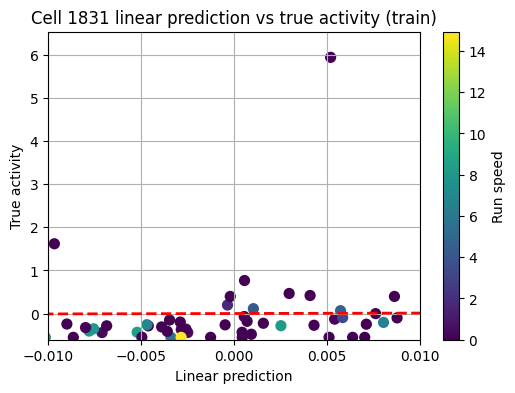

In [860]:
# choose a random cell and look at the linear fit and true activity on train times
eps = 0.01
cell_idx = np.random.randint(Y.shape[1])
y_pred_ln = Y_train_pred_plsridge[cell_idx]
y_true = Y[0][cell_idx]
eps_mask = (y_pred_ln >= -eps) & (y_pred_ln <= eps)
speed_min, speed_max = np.min(run_speed[train_t][eps_mask]), np.max(run_speed[train_t][eps_mask])

# plot
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_ln, y_true, c=run_speed[train_t], cmap='viridis', vmin=speed_min, vmax=speed_max, s=50)
cbar = plt.colorbar()
cbar.set_label('Run speed')
plt.xlabel('Linear prediction')
plt.ylabel('True activity')
plt.title(f'Cell {cell_idx} linear prediction vs true activity (train)')
# plt.xlim(np.percentile(y_pred_ln, 1), np.percentile(y_pred_ln, 99))
plt.plot([-1, 1], [-1, 1], 'r--', lw=2)

plt.xlim(-eps, eps)
eps_mask = (y_pred_ln >= -eps) & (y_pred_ln <= eps)
ymin, ymax = 1.1* np.min(y_true[eps_mask]), 1.1 * np.max(y_true[eps_mask])
plt.xticks(np.linspace(-eps, eps, 5))
plt.ylim(ymin, ymax)
plt.grid(True)
plt.show()


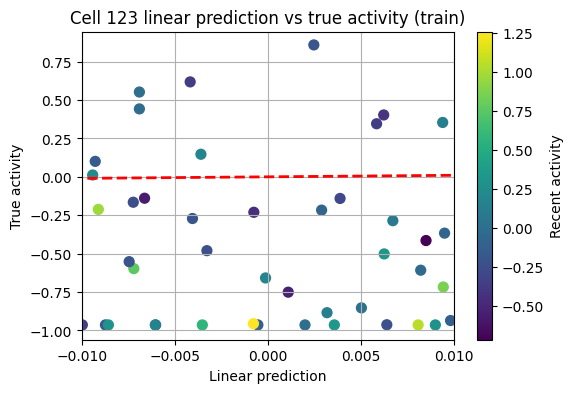

In [946]:
# choose a random cell and look at the linear fit and true activity on train times
eps = 0.01
cell_idx = np.random.randint(Y.shape[1])
y_pred_ln = Y_train_pred_plsridge[cell_idx]
y_true = Y[0][cell_idx]
eps_mask = (y_pred_ln >= -eps) & (y_pred_ln <= eps)
y_pred_crop = y_pred_ln[eps_mask]
y_true_crop = y_true[eps_mask]
# colour points by firing activity in previous time bins
history_window = 5
recent_activity = np.zeros_like(y_true_crop)
# loop through timepoints in cropped data abd compute recent activity in uncropped data
uncropped_indices = np.where(eps_mask)[0]
for idx, t in enumerate(uncropped_indices):
    recent_activity[idx] = np.mean(y_true[max(0, t - history_window):t])

# plot
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_crop, y_true_crop, c=recent_activity, cmap='viridis', s=50)
cbar = plt.colorbar()
cbar.set_label('Recent activity')
plt.xlabel('Linear prediction')
plt.ylabel('True activity')
plt.title(f'Cell {cell_idx} linear prediction vs true activity (train)')
plt.plot([-1, 1], [-1, 1], 'r--', lw=2)
plt.xlim(-eps, eps)
eps_mask = (y_pred_ln >= -eps) & (y_pred_ln <= eps)
ymin, ymax = 1.1* np.min(y_true[eps_mask]), 1.1 * np.max(y_true[eps_mask])
plt.xticks(np.linspace(-eps, eps, 5))
plt.ylim(ymin, ymax)
plt.grid(True)
plt.show()


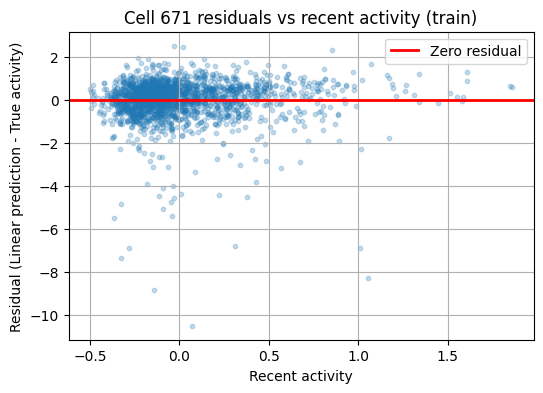

In [926]:
# choose a random cell and plot linear prediction - true activity against history activity
cell_idx = np.random.randint(Y.shape[1])
y_pred_ln = Y_train_pred_plsridge[cell_idx]
y_true = Y[0][cell_idx]
residuals = y_pred_ln - y_true
history_window = 10
residuals = residuals[history_window:]  # account for history window
recent_activity = np.zeros_like(residuals)
for t in range(history_window, len(y_true)):
    recent_activity[t - history_window] = np.mean(y_true[t - history_window:t])

# plot
plt.figure(figsize=(6, 4))
plt.scatter(recent_activity, residuals, s=10, alpha=0.25)
plt.xlabel('Recent activity')
plt.ylabel('Residual (Linear prediction - True activity)')
plt.title(f'Cell {cell_idx} residuals vs recent activity (train)')
plt.grid(True)
plt.axhline(0, color='r', linestyle='-', lw=2, label='Zero residual')
plt.legend()
plt.show()

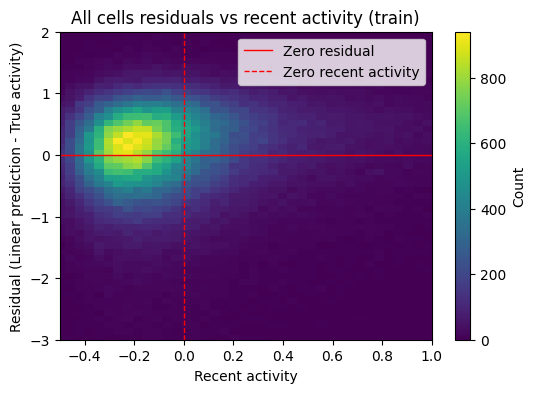

In [953]:
# plot average residual vs recent activity across all cells
history_window = 6
n_cells_sample = 100
residuals_all = []
recent_activity_all = []
cell_indices = np.random.choice(Y.shape[1], size=n_cells_sample, replace=False)
for cell_idx in cell_indices:
    y_pred_ln = Y_train_pred_plsridge[cell_idx]
    y_true = Y[0][cell_idx]
    residuals = y_pred_ln - y_true
    residuals = residuals[history_window:]  # account for history window
    recent_activity = np.zeros_like(residuals)
    for t in range(history_window, len(y_true)):
        recent_activity[t - history_window] = np.mean(y_true[t - history_window:t])
    residuals_all.append(residuals)
    recent_activity_all.append(recent_activity)
residuals_all = np.concatenate(residuals_all)
recent_activity_all = np.concatenate(recent_activity_all)

# plot 2d histogram
plt.figure(figsize=(6, 4))
plt.hist2d(recent_activity_all, residuals_all, bins=200, cmap='viridis')
cbar = plt.colorbar()
cbar.set_label('Count')
plt.xlabel('Recent activity')
plt.ylabel('Residual (Linear prediction - True activity)')
plt.title(f'All cells residuals vs recent activity (train)')
plt.xlim(-0.5, 1)
plt.ylim(-3, 2)
# plt.grid(True)
plt.axhline(0, color='r', linestyle='-', lw=1, label='Zero residual')
plt.axvline(0, color='r', linestyle='--', lw=1, label='Zero recent activity')   
plt.legend()
plt.show()

In [930]:
recent_activity_all

array([ 0.63653898,  0.68944424,  0.65570229, ..., -0.29457447,
       -0.25682965, -0.20358026], shape=(191000,))

In [20]:
# fit pls followed by a cell specific degree k polynomial nonlinearity
k = 3
Y_test_pred_pls_poly = np.zeros_like(Y[1])
for i in range(Y.shape[1]):
    # fit polynomial to Y_train_pred_pls
    p = Polynomial.fit(x=Y_train_pred_plsridge[i], y=Y[0][i], deg=k)
    Y_test_pred_pls_poly[i] = p(Y_test_pred_plsridge[i])
# compute train and test mse and corr
train_mse_pls_poly = mse(Y[0], Y_train_pred_plsridge)
test_mse_pls_poly = mse(Y[1], Y_test_pred_pls_poly)
train_corr_pls_poly = mean_row_corr(Y[0], Y_train_pred_plsridge, eps=EPS)
test_corr_pls_poly = mean_row_corr(Y[1], Y_test_pred_pls_poly, eps=EPS)
train_r2_pls_poly = var_explained(Y[0], Y_train_pred_plsridge, eps=EPS)
test_r2_pls_poly = var_explained(Y[1], Y_test_pred_pls_poly, eps=EPS)
print(f"PLS + Ridge + Polynomial Nonlinearity:")
print(f"  Train MSE: {train_mse_pls_poly:.4f}, Train Corr: {train_corr_pls_poly:.4f}, Train R^2: {train_r2_pls_poly:.4f}")
print(f"  Test MSE: {test_mse_pls_poly:.4f}, Test Corr: {test_corr_pls_poly:.4f}, Test R^2: {test_r2_pls_poly:.4f}")


PLS + Ridge + Polynomial Nonlinearity:
  Train MSE: 0.7992, Train Corr: 0.4149, Train R^2: 0.1947
  Test MSE: 0.8855, Test Corr: 0.3166, Test R^2: 0.1226


In [22]:
# fit pls followed by cell-specific exponential nonlinearity
Y_test_pred_pls_exp = np.zeros_like(Y[1])
for i in range(Y.shape[1]):
    # fit exponential to Y_train_pred_pls
    from scipy.optimize import curve_fit
    def exponential(x, lam, x0):
        return np.exp((x - x0) / lam)
    p_opt, _ = curve_fit(exponential, Y_train_pred_plsridge[i], Y[0][i], p0=[1.0, 0.1])
    Y_test_pred_pls_exp[i] = exponential(Y_test_pred_plsridge[i], *p_opt)
# compute train and test mse and corr
train_mse_pls_exp = mse(Y[0], Y_train_pred_plsridge)
test_mse_pls_exp = mse(Y[1], Y_test_pred_pls_exp)
train_corr_pls_exp = mean_row_corr(Y[0], Y_train_pred_plsridge, eps=EPS)
test_corr_pls_exp = mean_row_corr(Y[1], Y_test_pred_pls_exp, eps=EPS)
train_r2_pls_exp = var_explained(Y[0], Y_train_pred_plsridge, eps=EPS)
test_r2_pls_exp = var_explained(Y[1], Y_test_pred_pls_exp, eps=EPS)
print(f"PLS + Ridge + Exponential Nonlinearity:")
print(f"  Train MSE: {train_mse_pls_exp:.4f}, Train Corr: {train_corr_pls_exp:.4f}, Train R^2: {train_r2_pls_exp:.4f}")
print(f"  Test MSE: {test_mse_pls_exp:.4f}, Test Corr: {test_corr_pls_exp:.4f}, Test R^2: {test_r2_pls_exp:.4f}")

PLS + Ridge + Exponential Nonlinearity:
  Train MSE: 0.7992, Train Corr: 0.4149, Train R^2: 0.1947
  Test MSE: 0.9590, Test Corr: 0.2762, Test R^2: 0.0685


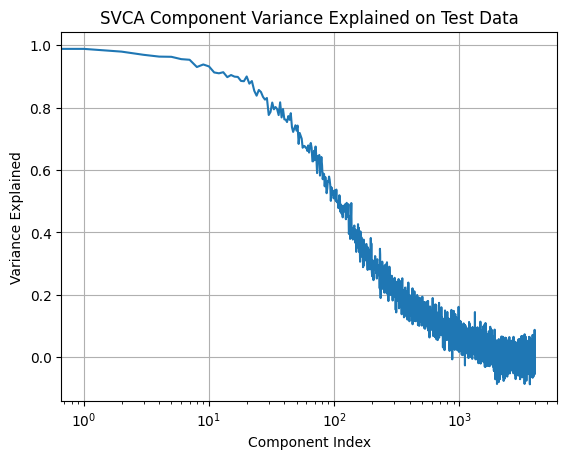

In [60]:
# plot the amount of variance explained by each component
plt.plot(svca_reliable_cov_frac)
plt.xscale('log')
# plt.yscale('log')
# plt.xlim(1, 1e3)
# plt.ylim(1e-5, 1e-1)
plt.xlabel("Component Index")
plt.ylabel("Variance Explained")
plt.title("SVCA Component Variance Explained on Test Data")
plt.grid()
plt.show()

Fitted power law slope: -1.2177


/tmp/ipykernel_1960447/760955294.py:12: RuntimeWarning: divide by zero encountered in power
  plt.plot(np.arange(len(svca_reliable_cov)), np.exp(intercept) * np.arange(len(svca_reliable_cov)) ** slope,


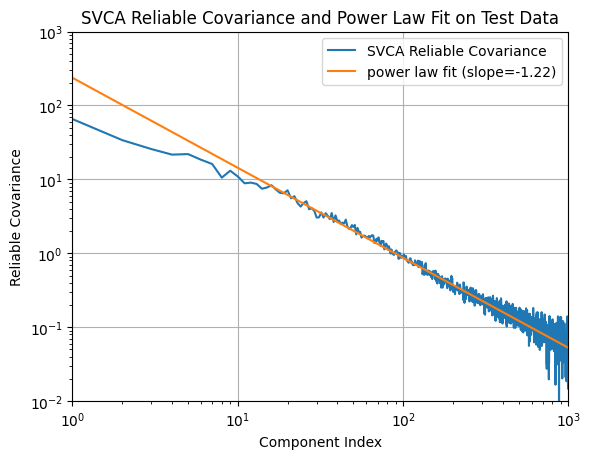

In [72]:
# fit power law to svca reliable cov
x_min, x_max = 10, 256
y = np.log(svca_reliable_cov[x_min:x_max])
x = np.log(np.arange(x_min, x_max))
# fit line with intercept
A = np.vstack([x, np.ones_like(x)]).T
slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
print(f"Fitted power law slope: {slope:.4f}")

# plot svca reliable cov and power law fit
plt.plot(svca_reliable_cov, label="SVCA Reliable Covariance")
plt.plot(np.arange(len(svca_reliable_cov)), np.exp(intercept) * np.arange(len(svca_reliable_cov)) ** slope,
         label=f'power law fit (slope={slope:.2f})')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1, 1e3)
plt.ylim(1e-2, 1e3)
plt.xlabel("Component Index")
plt.ylabel("Reliable Covariance")
plt.title("SVCA Reliable Covariance and Power Law Fit on Test Data")
plt.legend()
plt.grid()
plt.show()

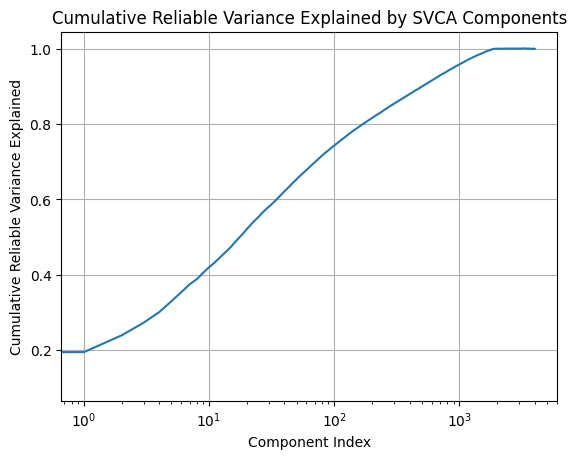

In [67]:
# plot cumulative reliable variance 
svca_reliable_cov_cum = np.cumsum(svca_reliable_cov / np.sum(svca_reliable_cov))
plt.plot(svca_reliable_cov_cum)
plt.xscale('log')
plt.xlabel("Component Index")
plt.ylabel("Cumulative Reliable Variance Explained")
plt.title("Cumulative Reliable Variance Explained by SVCA Components")
plt.grid()
plt.show()

In [119]:
# now do the same thing, but in kernel form
def kernel_rbf(X: np.ndarray, Y: np.ndarray, sigma: float = 1, eps: float = 1e-12) -> np.ndarray:
    """
    Compute the RBF (Gaussian) kernel matrix between two sets of vectors.
    Args:
        X: First input array of shape (n_cells_X, n_timepoints).
        Y: Second input array of shape (n_cells_Y, n_timepoints).
        sigma: Bandwidth parameter for the RBF kernel.
        eps: Small constant to avoid division by zero.
    Returns:
        K: Kernel matrix of shape (n_cells_X, n_cells_Y), where K[i, j] = exp(-||X[i] - Y[j]||^2 / (2 * sigma^2)).
    """
    X_norm = np.sum(X ** 2, axis=1).reshape(-1, 1)  # (n_cells_X, 1)
    Y_norm = np.sum(Y ** 2, axis=1).reshape(1, -1)  # (1, n_cells_Y)
    K = X_norm + Y_norm - 2 * (X @ Y.T)            # (n_cells_X, n_cells_Y)
    # divide by n_timepoints to get average squared distance
    K = K / X.shape[1]
    K = np.exp(-K / (2 * sigma ** 2 + eps))
    return K

In [162]:
K = kernel_rbf(X[0], X[0], sigma=1.0, eps=EPS)  # (p x p)
H = np.eye(K.shape[0]) - (1 / K.shape[0]) * np.ones((K.shape[0], K.shape[0]))
K = H @ K @ H
# compute SVD of K
U, S, Vt = np.linalg.svd(K, full_matrices=False)  # U: (p x p), Vt: (p x p)
# project data onto PCs
X_train_proj = U.T @ kernel_rbf(X[0], X[0], sigma=1.0, eps=EPS)

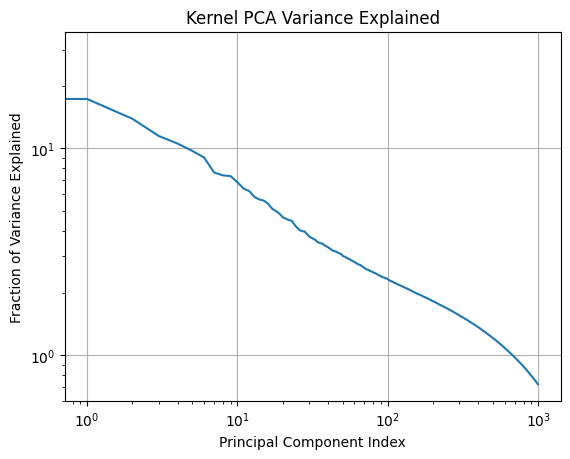

In [166]:
# plot variance in feature space
plt.plot(S[:int(1e3)])
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Principal Component Index")
plt.ylabel("Fraction of Variance Explained")
plt.title("Kernel PCA Variance Explained")
plt.grid()
plt.show()

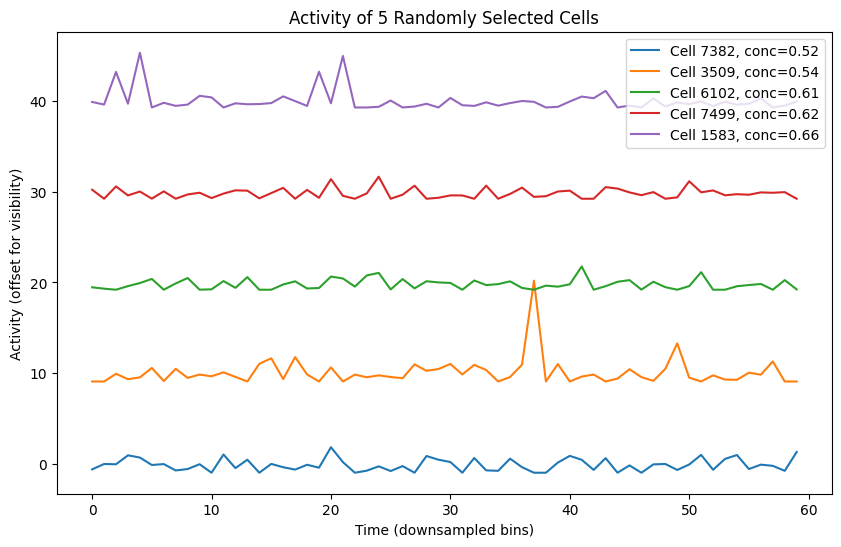

In [51]:
# choose 5 random cells and plot 
t_min, t_max = 0, 60
cell_indices = rng.choice(spks.shape[0], size=5, replace=False)
# order by cv
cell_indices = cell_indices[np.argsort(conc[cell_indices])]
plt.figure(figsize=(10, 6))
for i, cell_idx in enumerate(cell_indices):
    plt.plot(np.arange(t_min, t_max), spks[cell_idx, t_min:t_max] + i * 10, label=f'Cell {cell_idx}, conc={conc[cell_idx]:.2f}')
plt.xlabel('Time (downsampled bins)')
plt.ylabel('Activity (offset for visibility)')
plt.title('Activity of 5 Randomly Selected Cells')
plt.legend()
plt.show()